In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./chessfixed.csv')
df.head()

,FEN,move,value
0,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,d2d4,0.0387
1,rnbqkbnr/pppppppp/8/8/2P5/8/PP1PPPPP/RNBQKBNR ...,e7e5,-0.0598
2,rnbqkb1r/pppppppp/5n2/8/2P5/8/PP1PPPPP/RNBQKBN...,g1f3,0.0547
3,rnbqkb1r/pppppppp/5n2/8/2PP4/8/PP2PPPP/RNBQKBN...,c7c6,-0.0975
4,rnbqkb1r/ppp1pppp/3p1n2/8/2PP4/8/PP2PPPP/RNBQK...,b1c3,0.1782


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460133 entries, 0 to 1460132
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   FEN     1460133 non-null  str    
 1   move    1460133 non-null  str    
 2   value   1460133 non-null  float64
dtypes: float64(1), str(2)
memory usage: 113.4 MB


In [4]:
import chess

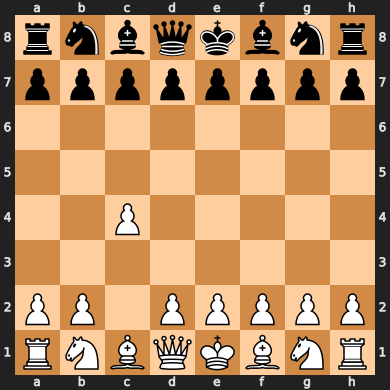

In [5]:
board = chess.Board(df.iloc[1].FEN)
board

In [6]:
print(str(board))

r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . P . . . . .
. . . . . . . .
P P . P P P P P
R N B Q K B N R


In [7]:
piece_map = {
        'P': 1, 'N': 2, 'B': 3, 'R': 4, 'Q': 5, 'K': 6,
        'p': -1, 'n': -2, 'b': -3, 'r': -4, 'q': -5, 'k': -6, '.': 0
    }
tokens = str(board).replace("\n", " ").split(" ")
numeric_flat = [piece_map[char] for char in tokens]


In [8]:
board.turn

False

In [9]:

piece_map = {
    'P': 1, 'N': 2, 'B': 3, 'R': 4, 'Q': 5, 'K': 6,
    'p': -1, 'n': -2, 'b': -3, 'r': -4, 'q': -5, 'k': -6, '.': 0
}

def fen_to_64(fen):
    board = chess.Board(fen)
    tokens = str(board).replace("\n", " ").split(" ")
    numeric_flat = [piece_map[char] for char in tokens]
    
    # Convert turn to int (1 for White, 0 for Black) and append it
    turn = int(board.turn)
    numeric_flat.append(turn)
    
    return numeric_flat


def expand_fen_dataframe(df, fen_column='FEN', chunk_size=5000):
    total_rows = len(df)
    # 64 squares + 1 column for turn
    column_names = [f"square_{i}" for i in range(64)] + ['turn']
    
    chunks = []
    for start_idx in range(0, total_rows, chunk_size):
        end_idx = min(start_idx + chunk_size, total_rows)
        chunk_fen = df[fen_column].iloc[start_idx:end_idx]
        
        # Convert chunk to a compact int8 numpy array (now 65 elements per row)
        matrix = np.array([fen_to_64(fen) for fen in chunk_fen], dtype=np.int8)
        
        chunk_df = pd.DataFrame(matrix, columns=column_names, index=chunk_fen.index)
        chunks.append(chunk_df)
        
    # Combine chunks back together
    expanded_df = pd.concat(chunks, axis=0)
    return pd.concat([df, expanded_df], axis=1)



df_final = expand_fen_dataframe(df, fen_column='FEN', chunk_size=50000)

In [10]:
df_final.head()

,FEN,move,value,square_0,square_1,square_2,square_3,square_4,square_5,square_6,...,square_55,square_56,square_57,square_58,square_59,square_60,square_61,square_62,square_63,turn
0,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,d2d4,0.0387,-4,-2,-3,-5,-6,-3,-2,...,1,4,2,3,5,6,3,2,4,1
1,rnbqkbnr/pppppppp/8/8/2P5/8/PP1PPPPP/RNBQKBNR ...,e7e5,-0.0598,-4,-2,-3,-5,-6,-3,-2,...,1,4,2,3,5,6,3,2,4,0
2,rnbqkb1r/pppppppp/5n2/8/2P5/8/PP1PPPPP/RNBQKBN...,g1f3,0.0547,-4,-2,-3,-5,-6,-3,0,...,1,4,2,3,5,6,3,2,4,1
3,rnbqkb1r/pppppppp/5n2/8/2PP4/8/PP2PPPP/RNBQKBN...,c7c6,-0.0975,-4,-2,-3,-5,-6,-3,0,...,1,4,2,3,5,6,3,2,4,0
4,rnbqkb1r/ppp1pppp/3p1n2/8/2PP4/8/PP2PPPP/RNBQK...,b1c3,0.1782,-4,-2,-3,-5,-6,-3,0,...,1,4,2,3,5,6,3,2,4,1


Anem a fer una regressió per predir el "value" o la possibilitat de guanyar donada una situació. 

No ens interessa el FEN ni el millor moviment, això és cosa de xarxes neuronals més complexes. 

Per una altra banda, els números positius i negatius aplicats a una regressió lineal podrien donar resultats erronis, ja que no signifiquen més o menys valor, sino que importa la seua posició. Si vulguerem fer una regressió tal vegada deuriem fer un one hot a cada posició, el que equivaldria a fer una "capa" per peça i color. 

In [11]:
df_onehot = pd.get_dummies(df_final, columns=[f"square_{i}" for i in range(64)] + ['turn'], prefix_sep='_' )

In [12]:
df_onehot.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460133 entries, 0 to 1460132
Columns: 805 entries, FEN to turn_1
dtypes: bool(802), float64(1), str(2)
memory usage: 1.2 GB


In [19]:
df_mostra = df_onehot.sample(n=50000, random_state=42)
df_mostra = df_mostra.reset_index(drop=True)

In [20]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split

target = 'value'

X = df_mostra.drop([target,"FEN","move"], axis=1)
y = df_mostra[target]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=13
)


reg_value = HistGradientBoostingRegressor()
reg_value.fit(X_train, y_train)




,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categoric

In [21]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = reg_value.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("The mean squared error (MSE) on test set: {:.4f}".format(mse))
print("R2: {:.4f}".format(r2))

The mean squared error (MSE) on test set: 0.1004
R2: 0.3234
